# 03 · Embeddings Patterns (All data)

This notebook joins events with embeddings, projects to 2D (UMAP), clusters (MiniBatchKMeans), and inspects cluster characteristics and nearest neighbors for high-friction examples.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import umap

from analysis.utils import load_all, add_time_features

dfs = load_all()
events = dfs['events']
emb = dfs['embeddings']

# TIMEZONE CORRECTION: Add 12 hours to correct database timestamp offset
events['ts'] = events['ts'] + pd.Timedelta(hours=12)

# Deduplicate any duplicate columns from CSV export
emb = emb.loc[:, ~emb.columns.duplicated()]

# Join keys
key_left = 'id' if 'id' in events.columns else None
if 'event_id' in emb.columns:
    key_right = 'event_id'
elif 'id' in emb.columns:
    key_right = 'id'
else:
    raise ValueError('Embeddings file missing event_id/id column')
if key_left is None:
    raise ValueError('Events file missing id column')

# Build embedding matrix
embed_cols = [c for c in emb.columns if c not in {key_right} and c.startswith(('e','dim_'))]
if not embed_cols and 'embedding' in emb.columns:
    import json
    # Parse JSON array strings into lists
    vecs = emb['embedding'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    max_len = int(vecs.dropna().map(len).median())
    mat = np.vstack(vecs.dropna().values)
    # Ensure consistent length
    if mat.shape[1] != max_len:
        mat = np.array([v[:max_len] for v in vecs.dropna().values])
    embed_cols = [f'e{i}' for i in range(mat.shape[1])]
    emb_numeric = pd.DataFrame(mat, columns=embed_cols, index=vecs.dropna().index)
    emb = emb.join(emb_numeric, how='left')
    embed_cols = [c for c in emb.columns if c.startswith('e')]

if not embed_cols:
    raise ValueError('Could not derive embedding columns from file')

subset = emb[[key_right] + embed_cols].copy()
subset[embed_cols] = subset[embed_cols].apply(pd.to_numeric, errors='coerce')

joined = events.merge(subset, left_on=key_left, right_on=key_right, how='inner')
joined = add_time_features(joined)

X = joined[embed_cols].fillna(0.0).astype(float).values
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

# 2D projection
X_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.05).fit_transform(X_scaled)
joined['umap_x'] = X_2d[:,0]
joined['umap_y'] = X_2d[:,1]

# Clustering
k = 12
kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
joined['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster sizes
joined['cluster'].value_counts().sort_index()


/Users/ommistry/observe_and_create/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
0    7471
Name: count, dtype: int64

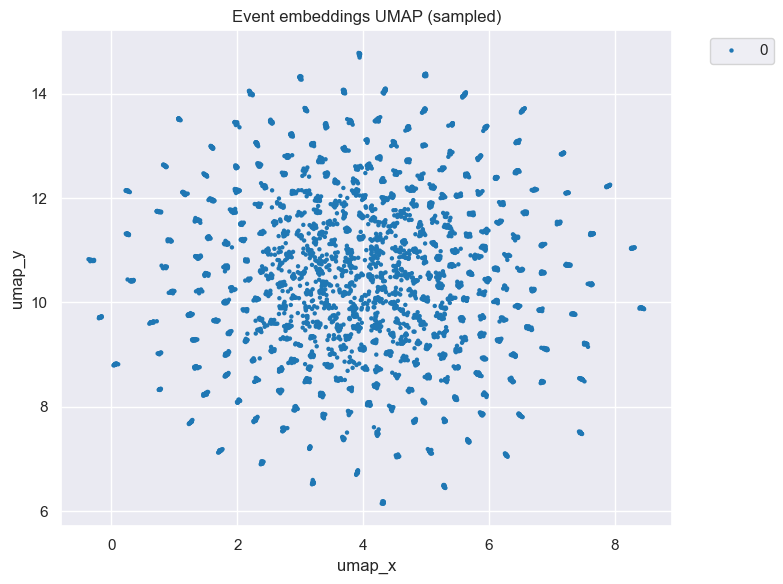

In [2]:
# Visualize UMAP with clusters
sns.set_theme()
plt.figure(figsize=(8,6))
sns.scatterplot(data=joined.sample(min(5000, len(joined)), random_state=42), x='umap_x', y='umap_y', hue='cluster', palette='tab20', s=10, linewidth=0)
plt.title('Event embeddings UMAP (sampled)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()


In [3]:
# Nearest neighbors for top-friction events (if available)

def is_friction(row):
    t = str(row.get('type','')).lower()
    return ('friction' in t) or ('rage' in t)

joined['is_friction'] = joined.apply(is_friction, axis=1)
friction_sample = joined[joined['is_friction']].head(10)

nn = NearestNeighbors(n_neighbors=6, metric='cosine').fit(X_scaled)
indices = []
for idx in friction_sample.index:
    i = joined.index.get_loc(idx)
    dists, inds = nn.kneighbors(X_scaled[i:i+1], n_neighbors=6)
    indices.append(inds[0].tolist())

nn_examples = []
for i, idxs in enumerate(indices):
    center = friction_sample.iloc[i]
    neigh = joined.iloc[idxs]
    nn_examples.append({
        'center_id': center['id'] if 'id' in center else None,
        'center_url': center.get('url', ''),
        'neighbors_urls': neigh['url'].tolist(),
        'neighbors_clusters': neigh['cluster'].tolist()
    })

pd.DataFrame(nn_examples)


,center_id,center_url,neighbors_urls,neighbors_clusters
0,0017b1af-8345-4d43-8282-6f425dec13e0,https://www.linkedin.com/school/y-combinator/p...,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
1,00220675-08f7-4ea7-ac6a-d9f46a098175,https://www.linkedin.com/feed/,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
2,002a53bd-42ae-452b-b28b-4f8fbd99de90,http://localhost:3000/dashboard,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
3,003c159e-70ad-43d2-b2da-1f2abd29e5a1,https://www.leen.dev/about,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
4,004252df-3b21-4da6-9f97-af30a662055a,https://www.linkedin.com/in/akillkumar/,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
5,00450717-358b-42a4-a9da-842ac87de170,https://www.claybird.com/,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
6,0066ea74-bb04-48de-bb07-1eff206034f1,https://www.theagi.company/,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
7,00703d8c-c2d6-46ae-9bee-662363e317f6,https://ieeexplore.ieee.org/document/9078759,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
8,00786195-2cb3-41cc-acf7-d5435ba3d48f,http://localhost:3000/dashboard,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
9,007f8ea5-14f2-4ac8-954c-fc72f19ad483,https://canvas.illinois.edu/courses/61800/assi...,[https://supabase.com/dashboard/project/mdtrlg...,"[0, 0, 0, 0, 0, 0]"
